In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

expenses = pd.read_csv('expenses.csv')
print(expenses.head())

         date       category   description  amount payment_method
0  2024-01-01           Food     Breakfast      80           Cash
1  2024-01-01      Transport      Bus fare      40           Cash
2  2024-01-02           Food         Lunch     120            UPI
3  2024-01-02  Entertainment  Movie ticket     250            UPI
4  2024-01-03      Groceries    Vegetables     300           Cash


In [3]:
print(expenses.columns)

Index(['date', 'category', 'description', 'amount', 'payment_method'], dtype='str')


In [4]:
print(expenses.describe())

            amount
count    90.000000
mean    564.155556
std    1052.617507
min      40.000000
25%     141.250000
50%     217.500000
75%     375.000000
max    8000.000000


In [5]:
print(expenses.dtypes)

date                str
category            str
description         str
amount            int64
payment_method      str
dtype: object


In [6]:
print(expenses.isnull())

     date  category  description  amount  payment_method
0   False     False        False   False           False
1   False     False        False   False           False
2   False     False        False   False           False
3   False     False        False   False           False
4   False     False        False   False           False
..    ...       ...          ...     ...             ...
85  False     False        False   False           False
86  False     False        False   False           False
87  False     False        False   False           False
88  False     False        False   False           False
89  False     False        False   False           False

[90 rows x 5 columns]


In [7]:
print(expenses.isnull().sum())

date              0
category          0
description       0
amount            0
payment_method    0
dtype: int64


In [8]:
print(expenses['payment_method'].value_counts())

payment_method
UPI     42
Cash    34
Card    14
Name: count, dtype: int64


In [9]:
print(expenses['category'].value_counts())

category
Food             30
Transport        15
Groceries        15
Entertainment    12
Bills            10
Shopping          8
Name: count, dtype: int64


In [11]:
print(expenses['date'].dtype)

str


In [12]:
expenses['date'] = pd.to_datetime(expenses['date'])
print(expenses['date'].dtype)

datetime64[us]


In [14]:
categories = expenses.groupby('category')['amount'].sum()
print(categories)

category
Bills            16286
Entertainment     4358
Food              4510
Groceries         9720
Shopping         13850
Transport         2050
Name: amount, dtype: int64


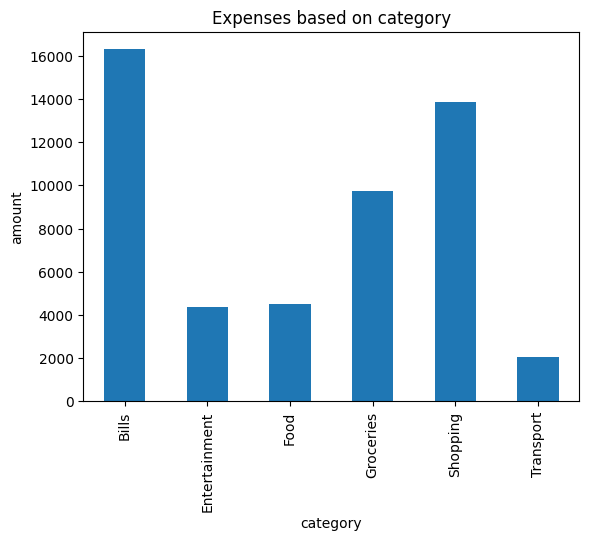

In [16]:
categories.plot(kind='bar',
    title='Expenses based on category',
    xlabel='category',
    ylabel='amount'
)

plt.show()

In [19]:
payment_methods = expenses.groupby('payment_method')['amount'].sum()
print(payment_methods)

payment_method
Card    22499
Cash     5435
UPI     22840
Name: amount, dtype: int64


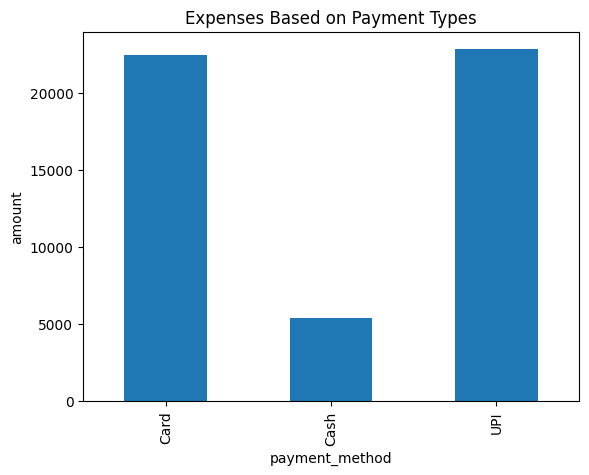

In [ ]:
payment_methods.plot(kind='bar',
    title='Expenses Based on Payment Types',
    xlabel='payment_method',
    ylabel='amount'
)
plt.show()

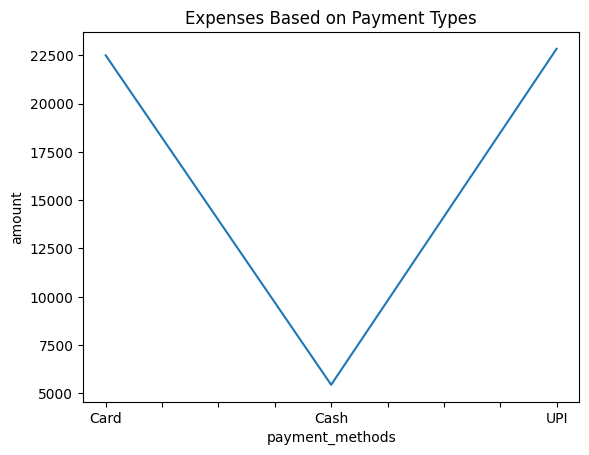

In [22]:
payment_methods.plot(
    title='Expenses Based on Payment Types',
    xlabel='payment_methods',
    ylabel='amount'
)

plt.show()

In [23]:
expenses_amount = expenses[['date','amount']].copy()
print(expenses_amount.head())

        date  amount
0 2024-01-01      80
1 2024-01-01      40
2 2024-01-02     120
3 2024-01-02     250
4 2024-01-03     300


<Axes: title={'center': 'Expenses'}>

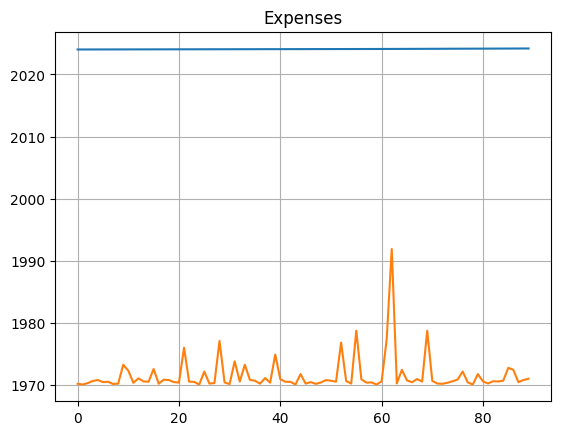

In [24]:
expenses_amount.plot(grid=True,title='Expenses',legend=False)

In [33]:
max_expenses = expenses.loc[expenses['amount'].idxmax()]
print(max_expenses)

date              2024-02-02 00:00:00
category                        Bills
description                      Rent
amount                           8000
payment_method                    UPI
Name: 62, dtype: object


In [34]:
min_expense = expenses.loc[expenses['amount'].idxmin()]
print(min_expense)

date              2024-01-01 00:00:00
category                    Transport
description                  Bus fare
amount                             40
payment_method                   Cash
Name: 1, dtype: object


In [38]:
monthly_expenses = expenses.groupby(expenses['date'].dt.month)['amount'].sum()
print(monthly_expenses)

date
1    28276
2    22498
Name: amount, dtype: int64


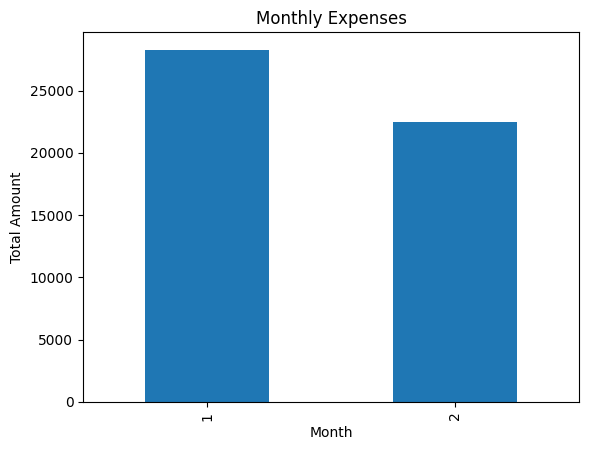

In [39]:
monthly_expenses.plot(kind='bar')
plt.title('Monthly Expenses')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.show() 

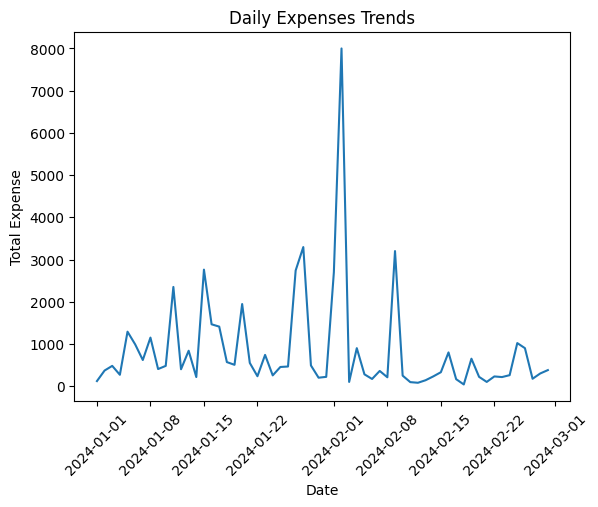

In [43]:
daily_expenses = expenses.groupby('date')['amount'].sum()

plt.figure()
plt.plot(daily_expenses.index,daily_expenses.values)
plt.title('Daily Expenses Trends')
plt.xlabel('Date')
plt.ylabel('Total Expense')
plt.xticks(rotation=45)
plt.show()


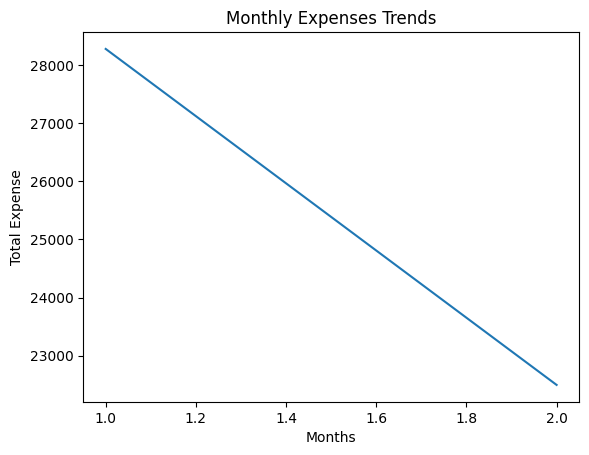

In [44]:
montly_expenses = expenses.resample('ME',on='date')['amount'].sum()

plt.figure()
plt.plot(monthly_expenses.index,monthly_expenses.values)
plt.title('Monthly Expenses Trends')
plt.xlabel('Months')
plt.ylabel('Total Expense')
plt.show()

In [45]:
expenses['daily_total'] = expenses.groupby('date')['amount'].transform('sum')
print(expenses.head())

        date       category   description  amount payment_method  daily_total
0 2024-01-01           Food     Breakfast      80           Cash          120
1 2024-01-01      Transport      Bus fare      40           Cash          120
2 2024-01-02           Food         Lunch     120            UPI          370
3 2024-01-02  Entertainment  Movie ticket     250            UPI          370
4 2024-01-03      Groceries    Vegetables     300           Cash          480


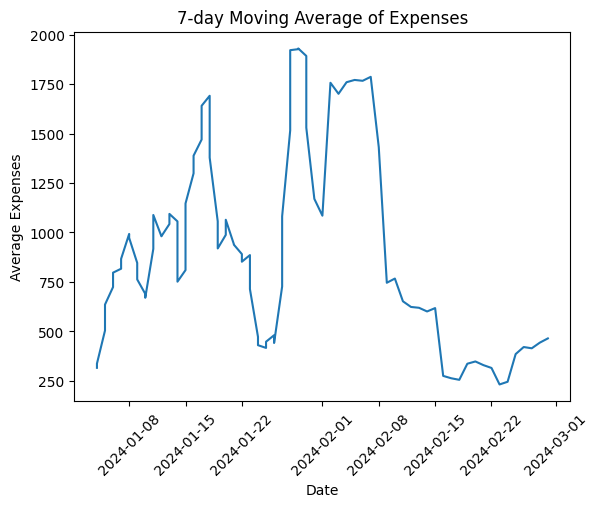

In [49]:
expenses = expenses.sort_values('date')
expenses['7_days_avg'] = expenses['daily_total'].rolling(window=7).mean()

plt.figure()
plt.plot(expenses['date'],expenses['7_days_avg'])
plt.title('7-day Moving Average of Expenses')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Average Expenses')
plt.show()